# TFT - Weekly Revenue Forecast (8-week horizon)

Ноутбук повторяет структуру статьи и минимально адаптирует её под weekly `City`-уровень проекта.

## 1. Загрузка и подготовка данных

In [2]:
import pandas as pd

In [3]:
import pandas as pd
import numpy as np
import holidays
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List

from darts import TimeSeries
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler, StaticCovariatesTransformer
from darts.utils.likelihood_models import QuantileRegression
from darts.explainability import TFTExplainer

import torch
import torchmetrics

from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.lr_monitor import LearningRateMonitor

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
d:\VS_project\tft_monthly_remainder_forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Формирование датафреймов target и covariates

In [4]:
# Читаем weekly-датасет проекта и приводим даты к ISO-неделям
df = pd.read_csv("../data/sales.csv", sep=";")
df["date"] = pd.to_datetime(df["Week"])
df = (
    df.groupby(["City", "date"], as_index=False)["revenue"]
    .sum()
    .sort_values(["City", "date"])
    .reset_index(drop=True)
)

# Восстанавливаем полный недельный грид по каждому городу
city_frames = []
for city, city_frame in df.groupby("City", sort=True):
    full_weeks = pd.date_range(city_frame["date"].min(), city_frame["date"].max(), freq="W-MON")
    city_grid = pd.DataFrame({"date": full_weeks})
    city_grid["City"] = city
    city_grid = city_grid.merge(city_frame, on=["City", "date"], how="left")
    city_grid["is_missing"] = city_grid["revenue"].isna().astype(int)
    city_grid["revenue"] = city_grid["revenue"].fillna(0.0)
    city_frames.append(city_grid)

df = pd.concat(city_frames, ignore_index=True).sort_values(["City", "date"]).reset_index(drop=True)
print(f"Series: {df['City'].nunique()}, Date range: {df['date'].min()} - {df['date'].max()}")
print(f"Total rows: {len(df)}")

Series: 50, Date range: 2022-01-03 00:00:00 - 2026-03-23 00:00:00
Total rows: 10464


In [5]:
# Календарные признаки известны на всём горизонте прогноза
iso_calendar = df["date"].dt.isocalendar()
df["week_of_year"] = iso_calendar.week.astype(int)
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["year"] = df["date"].dt.year

# Считаем число праздничных дней РФ внутри каждой ISO-недели
ru_holidays = holidays.country_holidays("RU")

def count_ru_holidays_in_week(row):
    week_holidays = pd.date_range(row["date"], periods=7, freq="D").date
    holiday_count = sum(day in ru_holidays for day in week_holidays)
    return holiday_count

df["is_holiday_week"] = df.apply(count_ru_holidays_in_week, axis=1)

# Лаги и rolling считаем только после shift(1), чтобы не было утечки
shifted = df.groupby("City")["revenue"].shift(1)
df["lag_1"] = shifted
df["lag_2"] = df.groupby("City")["revenue"].shift(2)
df["lag_4"] = df.groupby("City")["revenue"].shift(4)
df["lag_8"] = df.groupby("City")["revenue"].shift(8)
df["rolling_4"] = shifted.groupby(df["City"]).rolling(4).mean().reset_index(level=0, drop=True)
df["rolling_8"] = shifted.groupby(df["City"]).rolling(8).mean().reset_index(level=0, drop=True)
df["rolling_12"] = shifted.groupby(df["City"]).rolling(12).mean().reset_index(level=0, drop=True)

df_target = df[["date", "City", "revenue"]].copy()
df_past_covs = df[
    ["date", "City", "lag_1", "lag_2", "lag_4", "lag_8", "rolling_4", "rolling_8", "rolling_12"]
].copy()
df_future_covs = df[["date", "City", "week_of_year", "month", "quarter", "year", "is_holiday_week"]].copy()

display(df_target.head())
display(df_past_covs.head())
display(df_future_covs.head())

,date,City,revenue
0,2022-01-03,Arkhangelsk,1237343.94
1,2022-01-10,Arkhangelsk,1139750.43
2,2022-01-17,Arkhangelsk,1131688.16
3,2022-01-24,Arkhangelsk,1135912.90
4,2022-01-31,Arkhangelsk,1327978.58


,date,City,lag_1,lag_2,lag_4,lag_8,rolling_4,rolling_8,rolling_12
0,2022-01-03,Arkhangelsk,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-10,Arkhangelsk,1237343.94,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-17,Arkhangelsk,1139750.43,1237343.94,NaN,NaN,NaN,NaN,NaN
3,2022-01-24,Arkhangelsk,1131688.16,1139750.43,NaN,NaN,NaN,NaN,NaN
4,2022-01-31,Arkhangelsk,1135912.90,1131688.16,1237343.94,NaN,1.161174e+06,NaN,NaN


,date,City,week_of_year,month,quarter,year,is_holiday_week
0,2022-01-03,Arkhangelsk,1,1,1,2022,6
1,2022-01-10,Arkhangelsk,2,1,1,2022,0
2,2022-01-17,Arkhangelsk,3,1,1,2022,0
3,2022-01-24,Arkhangelsk,4,1,1,2022,0
4,2022-01-31,Arkhangelsk,5,1,1,2022,0


## 3. Формирование TimeSeries

In [6]:
# Добавляем будущие недели только для future covariates
ts_target_list = TimeSeries.from_group_dataframe(
    df=df_target.assign(City_static=df_target["City"]),
    group_cols="City",
    time_col="date",
    value_cols="revenue",
    static_cols=["City_static"],
    fill_missing_dates=True,
    freq="W-MON",
    fillna_value=0.0,
)

ts_past_covs_list = TimeSeries.from_group_dataframe(
    df=df_past_covs.fillna(0.0),
    group_cols="City",
    time_col="date",
    value_cols=["lag_1", "lag_2", "lag_4", "lag_8", "rolling_4", "rolling_8", "rolling_12"],
    fill_missing_dates=True,
    freq="W-MON",
    fillna_value=0.0,
)

future_rows = []
future_dates = pd.date_range(df["date"].max() + pd.Timedelta(weeks=1), periods=8, freq="W-MON")
for city in sorted(df_future_covs["City"].unique()):
    for future_date in future_dates:
        future_rows.append({"date": future_date, "City": city})

future_extension = pd.DataFrame(future_rows)
future_extension["week_of_year"] = future_extension["date"].dt.isocalendar().week.astype(int)
future_extension["month"] = future_extension["date"].dt.month
future_extension["quarter"] = future_extension["date"].dt.quarter
future_extension["year"] = future_extension["date"].dt.year
future_extension["is_holiday_week"] = future_extension.apply(count_ru_holidays_in_week, axis=1)

df_future_covs_extended = pd.concat([df_future_covs, future_extension], ignore_index=True)
ts_future_covs_list = TimeSeries.from_group_dataframe(
    df=df_future_covs_extended,
    group_cols="City",
    time_col="date",
    value_cols=["week_of_year", "month", "quarter", "year", "is_holiday_week"],
    fill_missing_dates=True,
    freq="W-MON",
    fillna_value=0.0,
)

print(f"Total series: {len(ts_target_list)}")

Total series: 50


## 4. Нормализация

In [7]:
# Масштабируем ряды по аналогии со статьёй, но под weekly-контракт проекта
target_series_scaler = Scaler(scaler=StandardScaler(), global_fit=False)
target_static_scaler = StaticCovariatesTransformer()
past_covs_scaler = Scaler(scaler=StandardScaler(), global_fit=False)
future_covs_scaler = Scaler(scaler=MinMaxScaler(feature_range=(0, 1)), global_fit=True)

ts_target_list = target_series_scaler.fit_transform(ts_target_list)
ts_target_list = target_static_scaler.fit_transform(ts_target_list)
ts_past_covs_list = past_covs_scaler.fit_transform(ts_past_covs_list)
ts_future_covs_list = future_covs_scaler.fit_transform(ts_future_covs_list)

## 5. Разделение на train / val / test

In [8]:
# Делаем article-style split с параметрами проекта: 60 недель истории и 8 недель горизонта
input_len = 60
output_len = 8
window_len = input_len + output_len

max_dt = df["date"].max()
test_min_dt = max_dt - pd.Timedelta(weeks=output_len - 1)
test_context_min_dt = test_min_dt - pd.Timedelta(weeks=input_len)
val_max_dt = test_min_dt - pd.Timedelta(weeks=1)
val_min_dt = val_max_dt - pd.Timedelta(weeks=window_len - 1)
train_min_dt = df["date"].min()
train_max_dt = val_min_dt - pd.Timedelta(weeks=1)

def series_splitter(series_list: List[TimeSeries]):
    train: List[TimeSeries] = []
    val: List[TimeSeries] = []
    test: List[TimeSeries] = []

    for series in tqdm(series_list):
        train_series = series[train_min_dt:train_max_dt]
        val_series = series[val_min_dt:val_max_dt]
        test_series = series[test_context_min_dt:max_dt]

        if len(train_series) >= window_len:
            train.append(train_series)
        if len(val_series) >= window_len:
            val.append(val_series)
        if len(test_series) >= window_len:
            test.append(test_series)

    return train, val, test

ts_target_train, ts_target_val, ts_target_test = series_splitter(ts_target_list)
ts_past_covs_train, ts_past_covs_val, ts_past_covs_test = series_splitter(ts_past_covs_list)
ts_future_covs_train, ts_future_covs_val, ts_future_covs_test = series_splitter(ts_future_covs_list)

100%|██████████| 50/50 [00:00<00:00, 1204.02it/s]


## 6. Создание и обучение TFT

In [9]:
# Обучаем TFT в конфигурации, близкой к статье, но адаптированной под weekly revenue
static_cat_embedding_sizes = {"City_static": len(df_target["City"].unique())}

encoders = {
    "cyclic": {"future": ["month"]},
}

tft_model = TFTModel(
    model_name="weekly_city_article_tft",
    input_chunk_length=input_len,
    output_chunk_length=output_len,
    batch_size=64,
    n_epochs=5,
    use_static_covariates=True,
    categorical_embedding_sizes=static_cat_embedding_sizes,
    add_encoders=encoders,
    hidden_size=64,
    lstm_layers=2,
    num_attention_heads=4,
    full_attention=True,
    hidden_continuous_size=16,
    work_dir="./logs",
    # Для повторных запусков ноутбука сбрасываем старые артефакты с тем же model_name
    force_reset=True,
    save_checkpoints=True,
    log_tensorboard=True,
    show_warnings=True,
    loss_fn=None,
    likelihood=QuantileRegression(
        quantiles=[0.1, 0.5, 0.9]
    ),
    torch_metrics=torchmetrics.WeightedMeanAbsolutePercentageError(),
    optimizer_cls=torch.optim.Adam,
    optimizer_kwargs={"lr": 1e-3},
    lr_scheduler_cls=torch.optim.lr_scheduler.ReduceLROnPlateau,
    lr_scheduler_kwargs={"mode": "min", "factor": 0.5, "patience": 2, "min_lr": 1e-6},
    pl_trainer_kwargs={
        "log_every_n_steps": 10,
        "callbacks": [
            EarlyStopping(monitor="val_loss", patience=3, mode="min"),
            LearningRateMonitor(logging_interval="epoch"),
        ]
    },
)

tft_model.fit(
    series=ts_target_train,
    past_covariates=ts_past_covs_train,
    future_covariates=ts_future_covs_train,
    val_series=ts_target_val,
    val_past_covariates=ts_past_covs_val,
    val_future_covariates=ts_future_covs_val,
    verbose=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0  

Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

d:\VS_project\tft_monthly_remainder_forecast\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


d:\VS_project\tft_monthly_remainder_forecast\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 4: 100%|██████████| 61/61 [00:10<00:00,  5.81it/s, v_num=logs, train_loss=0.401, val_loss=1.050, val_WeightedMeanAbsolutePercentageError=0.725, train_WeightedMeanAbsolutePercentageError=0.866]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 61/61 [00:10<00:00,  5.80it/s, v_num=logs, train_loss=0.401, val_loss=1.050, val_WeightedMeanAbsolutePercentageError=0.725, train_WeightedMeanAbsolutePercentageError=0.866]


TFTModel(output_chunk_shift=0, hidden_size=64, lstm_layers=2, num_attention_heads=4, full_attention=True, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=16, categorical_embedding_sizes={'City_static': 50}, add_relative_index=False, skip_interpolation=False, loss_fn=None, likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9], prior_strength=1.0), norm_type=LayerNorm, use_static_covariates=True, model_name=weekly_city_article_tft, input_chunk_length=60, output_chunk_length=8, batch_size=64, n_epochs=5, add_encoders={'cyclic': {'future': ['month']}}, work_dir=./logs, force_reset=True, save_checkpoints=True, log_tensorboard=True, show_warnings=True, torch_metrics=WeightedMeanAbsolutePercentageError(), optimizer_cls=<class 'torch.optim.adam.Adam'>, optimizer_kwargs={'lr': 0.001}, lr_scheduler_cls=<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, lr_scheduler_kwargs={'mode': 'min', 'factor': 0.5, 'patience': 2, 'min_lr': 1e-06}, pl_trainer_kwargs={'log_every_n_s

## 7. Выполнение прогнозов

In [10]:
ts_target_test_context = [series[:-output_len] for series in ts_target_test]
ts_target_test_actual = [series[-output_len:] for series in ts_target_test]
ts_past_covs_test_context = [series[:-output_len] for series in ts_past_covs_test]

# Отключаем notebook-progress bar Darts: без ipywidgets он падает на IProgress
tft_preds_scaled = tft_model.predict(
    n=output_len,
    series=ts_target_test_context,
    past_covariates=ts_past_covs_test_context,
    future_covariates=ts_future_covs_test,
    verbose=False,
    num_samples=200,
)
tft_preds = target_static_scaler.inverse_transform(tft_preds_scaled)
tft_preds = target_series_scaler.inverse_transform(tft_preds)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\VS_project\tft_monthly_remainder_forecast\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
Only 43 TimeSeries (lists) were provided which is lower than the number of series (n=50) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.


## 8. Оценка качества и визуализация

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=50) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.


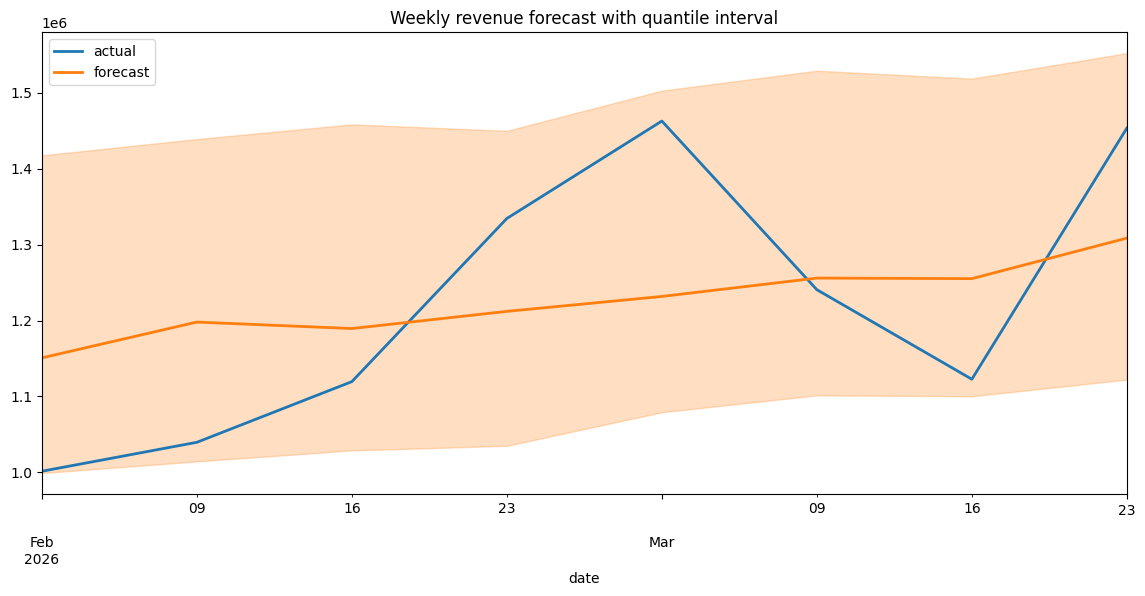

AttributeError: 'TimeSeries' object has no attribute 'quantile_timeseries'

In [11]:
def mape(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    denominator = np.where(np.abs(actual) == 0.0, 1e-9, np.abs(actual))
    return np.mean(np.abs(actual - predicted) / denominator)


def wape(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return np.sum(np.abs(actual - predicted)) / max(np.sum(np.abs(actual)), 1e-9)


series_idx = 0
actual_test = target_static_scaler.inverse_transform(ts_target_test_actual[series_idx])
actual_test = target_series_scaler.inverse_transform(actual_test)
pred_test = tft_preds[series_idx]

plt.figure(figsize=(14, 6))
actual_test.plot(label="actual")
pred_test.plot(label="forecast", low_quantile=0.1, high_quantile=0.9, central_quantile=0.5)
plt.legend()
plt.title("Weekly revenue forecast with quantile interval")
plt.show()

actual_values = actual_test.values().reshape(-1)
# В текущей версии Darts медианный прогноз достаём через quantile(0.5)
pred_values = pred_test.quantile(0.5).values().reshape(-1)

print("MAPE:", round(float(mape(actual_values, pred_values)), 4))
print("WAPE:", round(float(wape(actual_values, pred_values)), 4))

## 9. Интерпретация результатов

In [ ]:
try:
    explainer = TFTExplainer(
        tft_model,
        background_series=ts_target_test_context[0],
        background_past_covariates=ts_past_covs_test_context[0],
        background_future_covariates=ts_future_covs_test[0],
    )
    explainability_result = explainer.explain(
        foreground_series=ts_target_test_context[0],
        foreground_past_covariates=ts_past_covs_test_context[0],
        foreground_future_covariates=ts_future_covs_test[0],
    )
    explainer.plot_variable_selection(explainability_result)
    explainer.plot_attention(explainability_result, plot_type="all")
    explainer.plot_attention(explainability_result, plot_type="time")
except Exception as exc:
    print(f"TFT explainability skipped: {exc}")